In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPool2D
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix
import itertools

In [3]:
# carregando o dataset
cifar10 = tf.keras.datasets.cifar10

# carregando os dados
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# normalizando
X_train, X_test = X_train / 255, X_test / 255
# convertendo para um array
y_train, y_test = y_train.flatten(), y_test.flatten()

# formato dos dados
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)


In [4]:
# Número de classes de resposta
K = len(set(y_train))
print('Número de classes:', K)

Número de classes: 10


In [6]:
# criando a rede neural
i = Input(shape=X_train[0].shape)
x = Conv2D(32, (3,3), strides=2, activation='relu')(i)
x = Conv2D(64, (3,3), strides=2, activation='relu')(x)
x = Conv2D(128, (3,3), strides=2, activation='relu')(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(units=1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [7]:
# compilação
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [8]:
# treinamento
r = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.3792 - loss: 1.7000 - val_accuracy: 0.5563 - val_loss: 1.2371
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5690 - loss: 1.2071 - val_accuracy: 0.6135 - val_loss: 1.0852
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6299 - loss: 1.0327 - val_accuracy: 0.6160 - val_loss: 1.0804
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6868 - loss: 0.8896 - val_accuracy: 0.6703 - val_loss: 0.9362
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7195 - loss: 0.7855 - val_accuracy: 0.6832 - val_loss: 0.9194
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7560 - loss: 0.6903 - val_accuracy: 0.6913 - val_loss: 0.8963
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7852 - loss: 0.6101 - val_accuracy: 0.6967 - val_loss: 0.8964
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8127 -

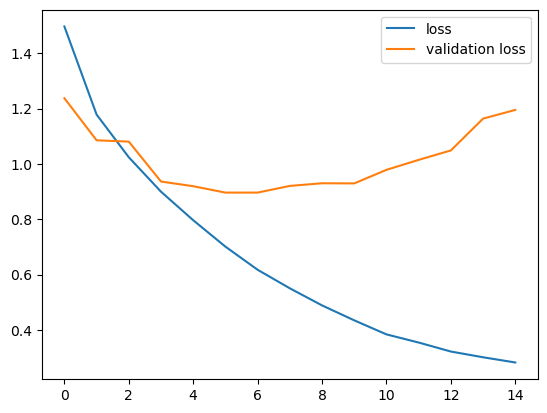

In [9]:
# grafico de comparação loss e validation loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='validation loss')
plt.legend()

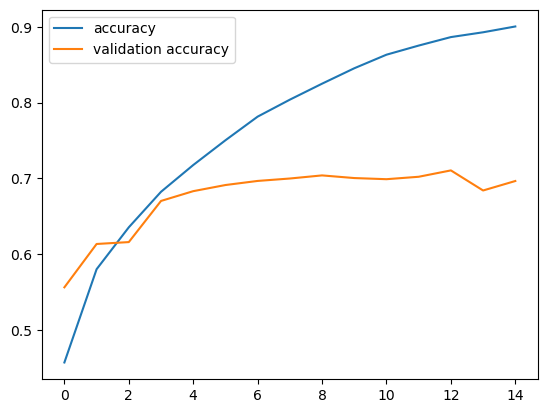

In [10]:
# grafico de comparação da accuracy e validation accuracy
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.legend()

In [16]:
# função para mostrar a matriz de confusão
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):

    # a função mostra a matriz de confusao, se normalize for
    # colocado como True, os valores serão normalizados

    if normalize:
        # normaliza os valores
        cm = cm.astype('float') /cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')

    else:
        print('confusion_matrix, without normalization')

    print(cm)

    # passando a matriz de confusão para mostrar    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    # titulo
    plt.title(title)
    # cores
    plt.colorbar()

    # define os nomes das classes
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # inserção do texto e formatação
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    # mostra as imagens e labels
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
confusion_matrix, without normalization
[[775  20  51  11  14   0   5  13  89  22]
 [ 29 805   5   7   7   4   8   9  48  78]
 [ 78   6 636  40  62  65  46  33  26   8]
 [ 36  13  88 426  68 194  76  47  37  15]
 [ 43   2 112  45 619  37  44  84  12   2]
 [ 23   4  90 126  43 584  31  61  28  10]
 [ 13  11  61  35  39  25 784  13  13   6]
 [ 26   4  49  27  36  45  14 777  10  12]
 [ 58  23  14   9   6   5   4   3 862  16]
 [ 63 107   7  11   5   9  11  26  63 698]]


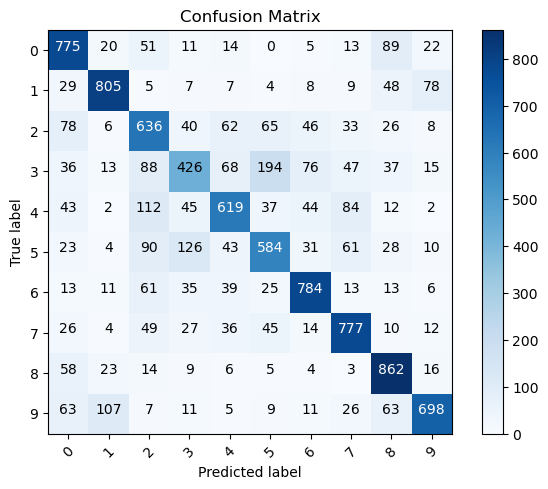

In [17]:
# testando a matriz de confusão
p_test = model.predict(X_test).argmax(axis=1) # fazendo previsões
cm = confusion_matrix(y_test, p_test) # matriz de confusão
plot_confusion_matrix(cm, list(range(10))) # função para mostrar matriz de confusão

In [18]:
# mapeando as labels
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

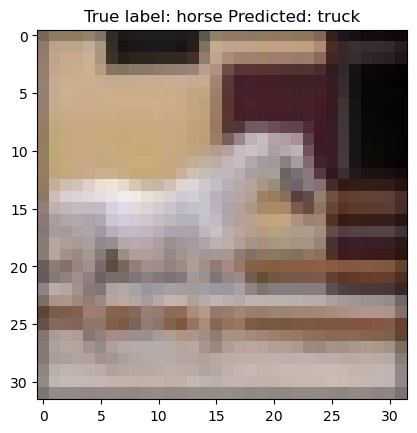

In [19]:
# Mostra exemplos errados
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(X_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]));